In [1]:
import sys
# sys.path.insert(0, '.')
import os
# Work around duplicate OpenMP runtime (conda numpy + pip torch both ship libomp.dylib).
# Must be set BEFORE importing torch/numpy, otherwise the process aborts (OMP: Error #15).
os.environ["KMP_DUPLICATE_LIB_OK"] = "TRUE"

import sys
# Kernel runs from src/; add the repo root so `from src.model import ...` resolves.
sys.path.insert(0, '..')

import torch
import torch.nn as nn
from torch.utils.data import DataLoader, Dataset
from torchvision import transforms
from torch.utils.tensorboard import SummaryWriter
from torchmetrics.classification import MulticlassF1Score
from PIL import Image
import pandas as pd
from tqdm import tqdm
from datetime import datetime
from torchvision import transforms
from src.model import *
from src.augmentations import AUGMENTATIONS #, get_train_transform, val_transform
from torch.utils.tensorboard import SummaryWriter
from torchmetrics.classification import MulticlassF1Score, MulticlassAccuracy, MulticlassPrecision, MulticlassRecall

/Users/rokaspranevicius/miniforge3/envs/mlp/lib/python3.11/site-packages/tqdm/auto.py:21: TqdmWarning: IProgress not found. Please update jupyter and ipywidgets. See https://ipywidgets.readthedocs.io/en/stable/user_install.html
  from .autonotebook import tqdm as notebook_tqdm


In [2]:
if torch.cuda.is_available():
    device = "cuda"
elif torch.backends.mps.is_available():
    device = "mps"
else:
    device = "cpu"
print(f"Using device: {device}")

Using device: mps


# Dataset

In [3]:
class ImageDataset(Dataset):
    def __init__(self, csv_path, split='train', transform=None):

        self.transform = transform
        
        full_df = pd.read_csv(csv_path)

        self.classes = sorted(full_df['label'].unique())
        self.class_to_idx = {cls: i for i, cls in enumerate(self.classes)}
        
        self.df = full_df[full_df['split'] == split].reset_index(drop=True)
        
        if len(self.df) == 0:
            raise ValueError(f"No samples found for split: {split}. Check your CSV or directory paths.")

    def __len__(self):
        return len(self.df)

    def __getitem__(self, idx):
        row = self.df.iloc[idx]
        img_path = row['abs_path']
        label_name = row['label']
        
        label = self.class_to_idx[label_name]

        try:
            image = Image.open(img_path).convert("RGB")
        except Exception as e:
            print(f"Error loading image {img_path}: {e}")
            raise e

        if self.transform:
            image = self.transform(image)

        return image, label

In [4]:
image_size = 96
base_pipeline = [
    transforms.Resize((image_size, image_size)),
    transforms.Grayscale(num_output_channels=3),
    transforms.ToTensor(),
    transforms.Normalize(mean=[0.485, 0.456, 0.406], std=[0.229, 0.224, 0.225])
]

csv_path = '../data/dataset.csv'

test_dataset = ImageDataset(csv_path=csv_path, split='test', transform=transforms.Compose(base_pipeline))
test_loader  = DataLoader(test_dataset, batch_size=32, shuffle=False)

In [5]:
num_classes=4
f1_metric = MulticlassF1Score(num_classes=num_classes, average=None).to(device)
macro_f1_metric = MulticlassF1Score(num_classes=num_classes, average='macro').to(device)
accuracy_metric = MulticlassAccuracy(num_classes=num_classes, average='macro').to(device)
precision_metric = MulticlassPrecision(num_classes=num_classes, average='macro').to(device)
recall_metric = MulticlassRecall(num_classes=num_classes, average='macro').to(device)
criterion = nn.CrossEntropyLoss()

# Testing

In [6]:
# Model registry: name -> (builder_fn, weights_dir).
# Add or remove a line here to add/remove a model from the evaluation.
MODEL_CONFIGS = {
    "hybrid_1": (build_vit_base_r50_s16_224, "../trained_clean_models/outputs_hybrid_01"),
    "hybrid_2": (build_vit_base_r50_s16_224, "../trained_clean_models/outputs_hybrid_02"),
    "hybrid_3": (build_vit_base_r50_s16_224, "../trained_clean_models/outputs_hybrid_03"),
    "vit_1": (build_vit_base_patch16_224, "../trained_clean_models/outputs_vit_01"),
    "vit_2": (build_vit_base_patch16_224, "../trained_clean_models/outputs_vit_02"),
    "vit_3": (build_vit_base_patch16_224, "../trained_clean_models/outputs_vit_03"),
}

In [7]:
metrics = [f1_metric, macro_f1_metric, accuracy_metric, precision_metric, recall_metric]

def evaluate_model(model):
    """Run the test set through `model` and return one metrics row (dict)."""
    model.eval()
    for m in metrics:
        m.to(device)
        m.reset()

    with torch.no_grad():
        for img, labels in test_loader:
            img, labels = img.to(device), labels.to(device)
            out = model(img)
            for m in metrics:
                m.update(out, labels)

    row = {
        "Accuracy":  accuracy_metric.compute().item(),
        "Macro_F1":  macro_f1_metric.compute().item(),
        "Precision": precision_metric.compute().item(),
        "Recall":    recall_metric.compute().item(),
    }
    for i, score in enumerate(f1_metric.compute().tolist()):
        row[f"Class_{i}_F1"] = score
    return row

In [8]:
results = []
print(f"\n{'='*30}\nStarting Test Set Evaluation\n{'='*30}")
print('--->', os.getcwd())

for model_name, (builder, weights_dir) in MODEL_CONFIGS.items():
    for aug_name in AUGMENTATIONS.keys():
        path = f"{weights_dir}/best_vit_model_96x96_{aug_name}_0.1.pth"

        # Load weights first so a missing checkpoint skips before we pay the
        # pretrained-weight download that building the model triggers.
        try:
            state = torch.load(path, map_location=device, weights_only=True)
        except FileNotFoundError:
            print(f"Skipping {model_name}/{aug_name}: {path} not found.")
            continue

        print(f"Evaluating {model_name} / {aug_name}...")
        model = builder(num_classes=num_classes, img_size=image_size).to(device)
        model.load_state_dict(state)

        row = {"Model": model_name, "Augmentation": aug_name, **evaluate_model(model)}
        results.append(row)

        del model
        torch.cuda.empty_cache()

df = pd.DataFrame(results)
df


Starting Test Set Evaluation
---> /Users/rokaspranevicius/Documents/Aca/UniversityOfEdinburgh/Defending_ViTs/Defending-Vision-Transformers/src
Evaluating hybrid_1 / baseline...


Evaluating hybrid_1 / snp_5%(default)...
Evaluating hybrid_1 / patch_16x16_9...
Evaluating hybrid_1 / gaussian_blur...
Evaluating hybrid_1 / gaussian_noise_greyscale...
Evaluating hybrid_1 / patch_16x16_18_snp_fillup...
Evaluating hybrid_1 / grid_patch_16x16_4...
Evaluating hybrid_1 / grid_patch_16x16_18_snp_fillup...
Evaluating hybrid_1 / grid_patch_16x16_9_snp_fillup...
Evaluating hybrid_2 / baseline...
Evaluating hybrid_2 / snp_5%(default)...
Evaluating hybrid_2 / patch_16x16_9...
Evaluating hybrid_2 / gaussian_blur...
Evaluating hybrid_2 / gaussian_noise_greyscale...
Evaluating hybrid_2 / patch_16x16_18_snp_fillup...
Evaluating hybrid_2 / grid_patch_16x16_4...
Evaluating hybrid_2 / grid_patch_16x16_18_snp_fillup...
Evaluating hybrid_2 / grid_patch_16x16_9_snp_fillup...
Evaluating hybrid_3 / baseline...
Evaluating hybrid_3 / snp_5%(default)...
Evaluating hybrid_3 / patch_16x16_9...
Evaluating hybrid_3 / gaussian_blur...
Evaluating hybrid_3 / gaussian_noise_greyscale...
Evaluating hy

,Model,Augmentation,Accuracy,Macro_F1,Precision,Recall,Class_0_F1,Class_1_F1,Class_2_F1,Class_3_F1
0,hybrid_1,baseline,0.943769,0.941375,0.939950,0.943769,0.915406,0.929548,0.947988,0.972558
1,hybrid_1,snp_5%(default),0.972808,0.970355,0.969978,0.972808,0.944318,0.963955,0.976471,0.996678
2,hybrid_1,patch_16x16_9,0.907543,0.915724,0.932575,0.907543,0.904378,0.904313,0.893989,0.960215
3,hybrid_1,gaussian_blur,0.943883,0.943281,0.943075,0.943883,0.919248,0.939746,0.943170,0.970959
4,hybrid_1,gaussian_noise_greyscale,0.958661,0.955480,0.952742,0.958661,0.932166,0.946974,0.953307,0.989474
5,hybrid_1,patch_16x16_18_snp_fillup,0.914242,0.917573,0.929060,0.914242,0.887456,0.884190,0.931563,0.967083
6,hybrid_1,grid_patch_16x16_4,0.933648,0.933989,0.934843,0.933648,0.913212,0.932221,0.917671,0.972853
7,hybrid_1,grid_patch_16x16_18_snp_fillup,0.951867,0.953871,0.958138,0.951867,0.929054,0.941296,0.950153,0.994980
8,hybrid_1,grid_patch_16x16_9_snp_fillup,0.958455,0.957285,0.958007,0.958455,0.931973,0.953799,0.949455,0.993913
9,hybrid_2,baseline,0.960151,0.956765,0.957232,0.960151,0.923523,0.945066,0.967868,0.990603


In [9]:
# Compare Macro-F1 across models, one column per model.
df.pivot(index="Augmentation", columns="Model", values="Macro_F1")

Model,hybrid_1,hybrid_2,hybrid_3,vit_1,vit_2,vit_3
Augmentation,,,,,,
baseline,0.941375,0.956765,0.963826,0.929943,0.916754,0.870467
gaussian_blur,0.943281,0.952150,0.922586,0.934334,0.937906,0.910411
gaussian_noise_greyscale,0.955480,0.968062,0.919341,0.878176,0.865607,0.908258
grid_patch_16x16_18_snp_fillup,0.953871,0.963628,0.951627,0.932723,0.901910,0.896779
grid_patch_16x16_4,0.933989,0.968953,0.966154,0.921085,0.938832,0.934501
grid_patch_16x16_9_snp_fillup,0.957285,0.951606,0.941677,0.935981,0.921742,0.950606
patch_16x16_18_snp_fillup,0.917573,0.936572,0.961340,0.951192,0.913291,0.920948
patch_16x16_9,0.915724,0.923522,0.970191,0.944723,0.957377,0.925750
snp_5%(default),0.970355,0.936850,0.965998,0.931627,0.947861,0.946157


In [11]:
df.to_csv("../trained_clean_models/vitANDhybrid_clean_MRI_results.csv", index=False)

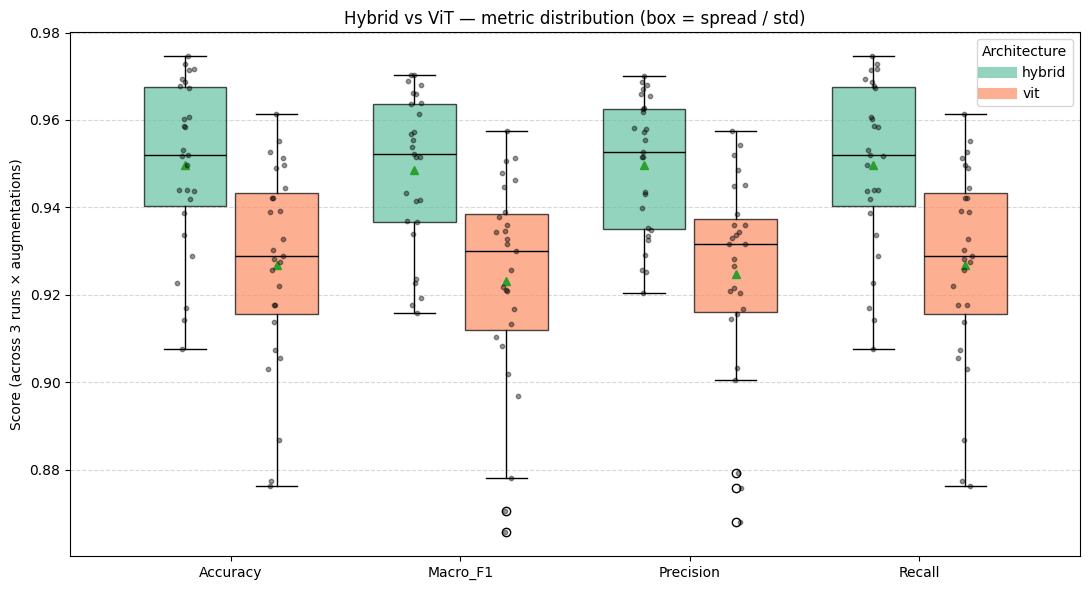

             Accuracy         Macro_F1         Precision          Recall  \
                 mean     std     mean     std      mean     std    mean   
Architecture                                                               
hybrid         0.9498  0.0193   0.9485  0.0176    0.9496  0.0155  0.9498   
vit            0.9269  0.0230   0.9231  0.0242    0.9247  0.0231  0.9269   

                      
                 std  
Architecture          
hybrid        0.0193  
vit           0.0230  


In [12]:
import numpy as np
import matplotlib.pyplot as plt

# Box plot comparing hybrid vs vit. The 3 runs per architecture (hybrid_1/2/3,
# vit_1/2/3) are pooled, so each box's spread = variability across runs AND
# augmentation types, i.e. the model's std.
plot_metrics = ["Accuracy", "Macro_F1", "Precision", "Recall"]
arch = df["Model"].str.replace(r"_\d+$", "", regex=True)   # hybrid_1 -> hybrid
arch_order = list(dict.fromkeys(arch))                      # first-seen: hybrid, vit
colors = plt.cm.Set2.colors

fig, ax = plt.subplots(figsize=(11, 6))
n = len(arch_order)
width = 0.8 / max(n, 1)

for j, a in enumerate(arch_order):
    sub = df[arch == a]
    data = [sub[met].values for met in plot_metrics]
    positions = np.arange(len(plot_metrics)) + (j - (n - 1) / 2) * width
    bp = ax.boxplot(data, positions=positions, widths=width * 0.9,
                    patch_artist=True, showmeans=True,
                    medianprops=dict(color="black"))
    for box in bp["boxes"]:
        box.set(facecolor=colors[j % len(colors)], alpha=0.7)
    # jittered points so every run/augmentation is visible
    for k, vals in enumerate(data):
        x = np.random.normal(positions[k], width * 0.05, size=len(vals))
        ax.scatter(x, vals, color="black", s=10, alpha=0.4, zorder=3)
    ax.plot([], [], color=colors[j % len(colors)], linewidth=8, alpha=0.7, label=a)

ax.set_xticks(np.arange(len(plot_metrics)))
ax.set_xticklabels(plot_metrics)
ax.set_ylabel("Score (across 3 runs × augmentations)")
ax.set_title("Hybrid vs ViT — metric distribution (box = spread / std)")
ax.grid(axis="y", linestyle="--", alpha=0.5)
ax.legend(title="Architecture")

plt.tight_layout()
plt.show()

# Numeric mean ± std per architecture, for reference
print(df.assign(Architecture=arch).groupby("Architecture")[plot_metrics]
        .agg(["mean", "std"]).round(4))

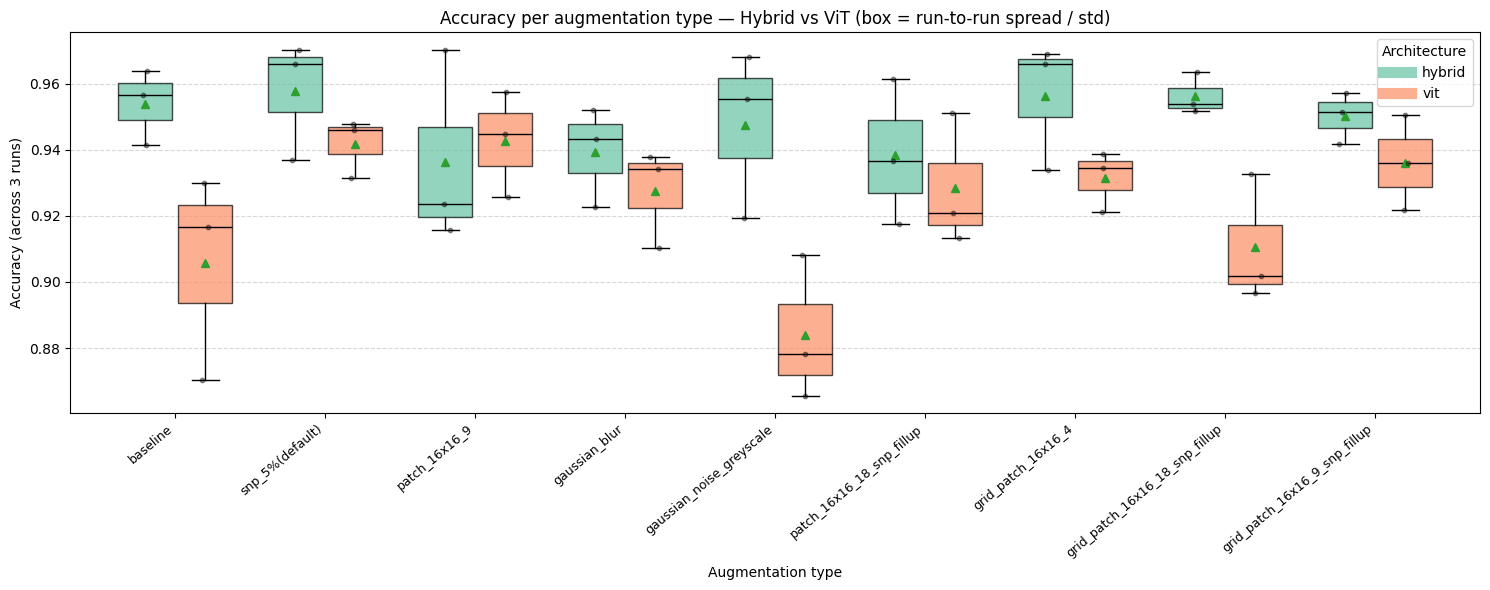

In [16]:
import numpy as np
import matplotlib.pyplot as plt

# Accuracy box plot: one group per augmentation type, hybrid vs vit within each.
# Each box pools the 3 runs (hybrid_1/2/3 or vit_1/2/3), so its spread = run-to-run std.
arch = df["Model"].str.replace(r"_\d+$", "", regex=True)   # hybrid_1 -> hybrid
arch_order = list(dict.fromkeys(arch))                      # first-seen: hybrid, vit
aug_order = list(df["Augmentation"].unique())
colors = plt.cm.Set2.colors

fig, ax = plt.subplots(figsize=(15, 6))
n = len(arch_order)
width = 0.8 / max(n, 1)

for j, a in enumerate(arch_order):
    sub = df[arch == a]
    data = [sub.loc[sub["Augmentation"] == aug, "Macro_F1"].values for aug in aug_order]
    positions = np.arange(len(aug_order)) + (j - (n - 1) / 2) * width
    bp = ax.boxplot(data, positions=positions, widths=width * 0.9,
                    patch_artist=True, showmeans=True,
                    medianprops=dict(color="black"))
    for box in bp["boxes"]:
        box.set(facecolor=colors[j % len(colors)], alpha=0.7)
    for k, vals in enumerate(data):
        x = np.random.normal(positions[k], width * 0.05, size=len(vals))
        ax.scatter(x, vals, color="black", s=10, alpha=0.4, zorder=3)
    ax.plot([], [], color=colors[j % len(colors)], linewidth=8, alpha=0.7, label=a)

ax.set_xticks(np.arange(len(aug_order)))
ax.set_xticklabels(aug_order, rotation=40, ha="right", fontsize=9)
ax.set_ylabel("Accuracy (across 3 runs)")
ax.set_xlabel("Augmentation type")
ax.set_title("Accuracy per augmentation type — Hybrid vs ViT (box = run-to-run spread / std)")
ax.grid(axis="y", linestyle="--", alpha=0.5)
ax.legend(title="Architecture")

plt.tight_layout()
plt.show()